### 1. Problem Definition
- Predict the prices of used cars.
- Since price is a continuous value, the model will employ a regression analysis.
- Success metrics: MSE, RMSE, R2 Score
- Inputs: model, year, transmission, mileage, fuelType, tax, mpg, engineSize 
- Target Column: price

### 2. Load Dataset and Inspection

In [1]:
# 1. Import Dependencies
import pandas as pd
import numpy as np

import kagglehub

import os

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from category_encoders import TargetEncoder

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.dummy import DummyRegressor
from scikeras.wrappers import KerasRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error

from sklearn.model_selection import cross_validate, KFold

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

In [2]:
# 2.1. Download dataset
path = kagglehub.dataset_download('adityadesai13/used-car-dataset-ford-and-mercedes', output_dir='../data/', force_download=True)

# 2.2. Rename mispelled file
os.rename(f'{path}/hyundi.csv', f'{path}/hyundai.csv')

# 2.3. Filter and load only clean files
exclude = ['cclass.csv', 'focus.csv', 'unclean cclass.csv', 'unclean focus.csv']

clean_files = [f for f in os.listdir(path) if f.endswith('.csv') and f not in exclude]

# 2.4. Create dataframes per each file
dfs = []
for f in clean_files:
    sub_df = pd.read_csv(f'{path}/{f}')
    sub_df['brand'] = f.replace('.csv', '')
    dfs.append(sub_df)

# 2.5. Create combined df
df = pd.concat(dfs, ignore_index=True)
df

100%|██████████| 1.10M/1.10M [00:28<00:00, 39.9kB/s]

Extracting files...


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,brand,tax(£)
0,A1,2017,12500,Manual,15735,Petrol,150.0,55.4,1.4,audi,NaN
1,A6,2016,16500,Automatic,36203,Diesel,20.0,64.2,2.0,audi,NaN
2,A1,2016,11000,Manual,29946,Petrol,30.0,55.4,1.4,audi,NaN
3,A4,2017,16800,Automatic,25952,Diesel,145.0,67.3,2.0,audi,NaN
4,A3,2019,17300,Manual,1998,Petrol,145.0,49.6,1.0,audi,NaN
...,...,...,...,...,...,...,...,...,...,...,...
99182,Eos,2012,5990,Manual,74000,Diesel,125.0,58.9,2.0,vw,NaN
99183,Fox,2008,1799,Manual,88102,Petrol,145.0,46.3,1.2,vw,NaN
99184,Fox,2009,1590,Manual,70000,Petrol,200.0,42.0,1.4,vw,NaN
99185,Fox,2006,1250,Manual,82704,Petrol,150.0,46.3,1.2,vw,NaN


In [3]:
# 3. Inspect shape, dtypes, and first rows
print(f'Shape: {df.shape}\n')

print('Data Types:')
print(f'{df.info()}\n')

print(f'First 10 rows:\n{df.head(10)}')

Shape: (99187, 11)

Data Types:
<class 'pandas.DataFrame'>
RangeIndex: 99187 entries, 0 to 99186
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         99187 non-null  str    
 1   year          99187 non-null  int64  
 2   price         99187 non-null  int64  
 3   transmission  99187 non-null  str    
 4   mileage       99187 non-null  int64  
 5   fuelType      99187 non-null  str    
 6   tax           94327 non-null  float64
 7   mpg           99187 non-null  float64
 8   engineSize    99187 non-null  float64
 9   brand         99187 non-null  str    
 10  tax(£)        4860 non-null   float64
dtypes: float64(4), int64(3), str(4)
memory usage: 10.6 MB
None

First 10 rows:
  model  year  price transmission  mileage fuelType    tax   mpg  engineSize  \
0    A1  2017  12500       Manual    15735   Petrol  150.0  55.4         1.4   
1    A6  2016  16500    Automatic    36203   Diesel   20.0  64.2       

In [4]:
# 4. Statistical summary
df.describe

<bound method NDFrame.describe of       model  year  price transmission  mileage fuelType    tax   mpg  \
0        A1  2017  12500       Manual    15735   Petrol  150.0  55.4   
1        A6  2016  16500    Automatic    36203   Diesel   20.0  64.2   
2        A1  2016  11000       Manual    29946   Petrol   30.0  55.4   
3        A4  2017  16800    Automatic    25952   Diesel  145.0  67.3   
4        A3  2019  17300       Manual     1998   Petrol  145.0  49.6   
...     ...   ...    ...          ...      ...      ...    ...   ...   
99182   Eos  2012   5990       Manual    74000   Diesel  125.0  58.9   
99183   Fox  2008   1799       Manual    88102   Petrol  145.0  46.3   
99184   Fox  2009   1590       Manual    70000   Petrol  200.0  42.0   
99185   Fox  2006   1250       Manual    82704   Petrol  150.0  46.3   
99186   Fox  2007   2295       Manual    74000   Petrol  145.0  46.3   

       engineSize brand  tax(£)  
0             1.4  audi     NaN  
1             2.0  audi     NaN  

### 3. Exploratory Data Analaysis (EDA)

In [5]:
# 1. Count missing values per column
df.isna().sum()

model               0
year                0
price               0
transmission        0
mileage             0
fuelType            0
tax              4860
mpg                 0
engineSize          0
brand               0
tax(£)          94327
dtype: int64

In [6]:
# 2. Count duplicate rows
df.duplicated().sum()

np.int64(1475)

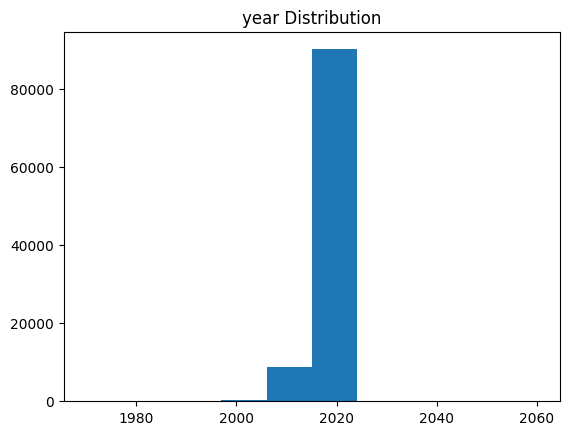

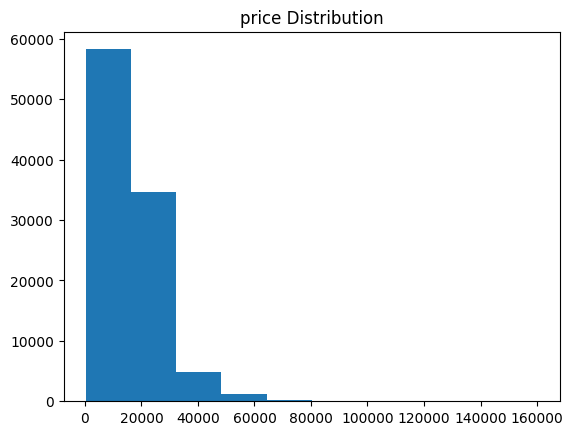

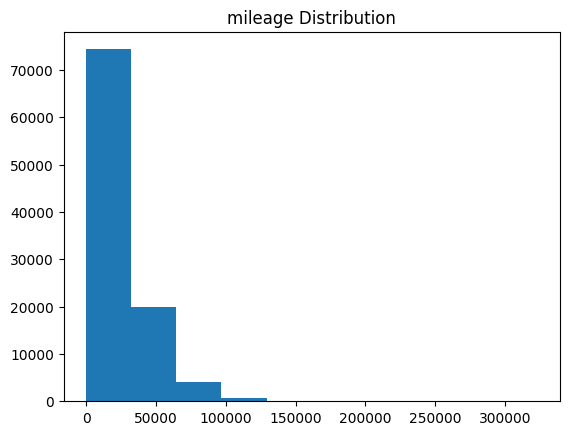

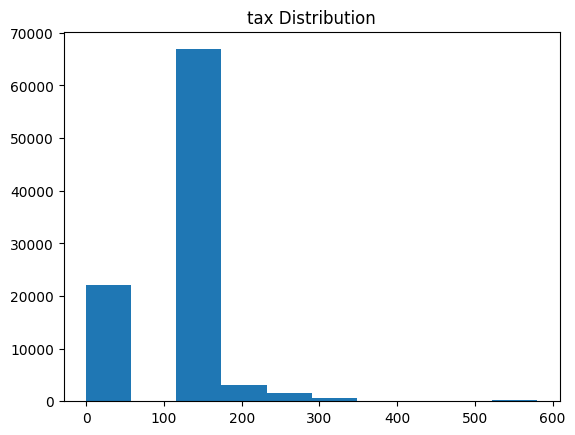

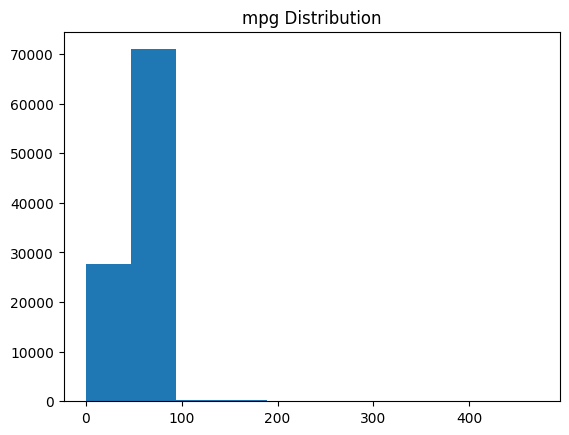

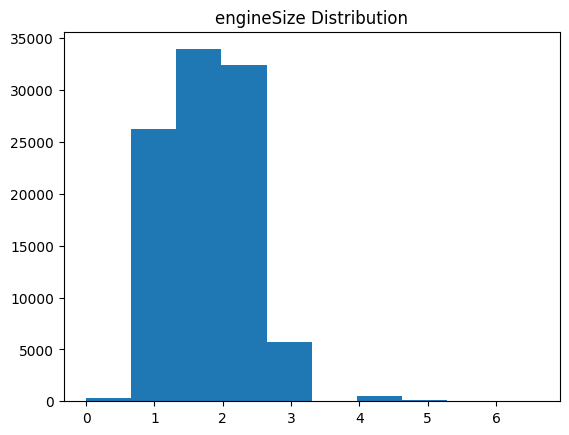

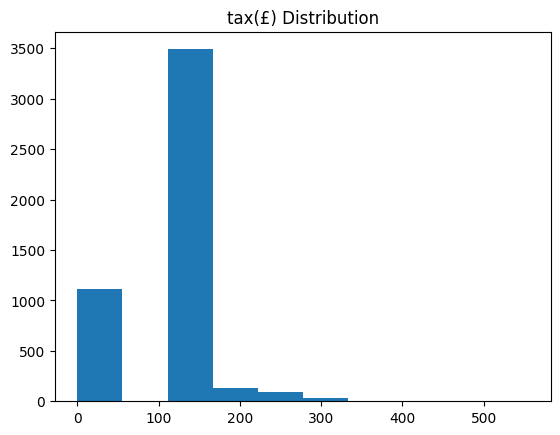

In [7]:
# 3. Plot distributions of numerical features
numerical_cols = [col for col in df.columns if (df[col].dtype != 'str') and (df[col].dtype != 'object')]

for i in numerical_cols:
    plt.hist(df[i])
    plt.title(f'{df[i].name} Distribution')
    plt.show()

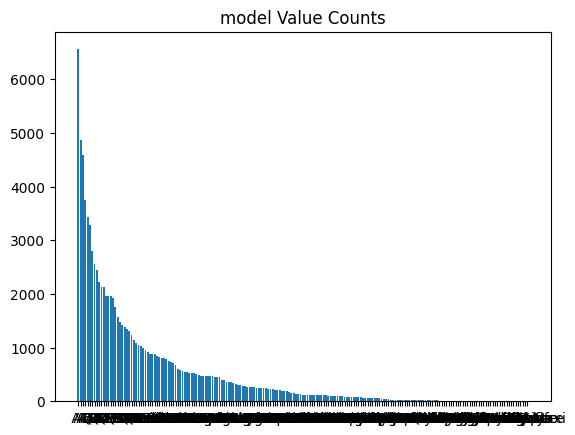

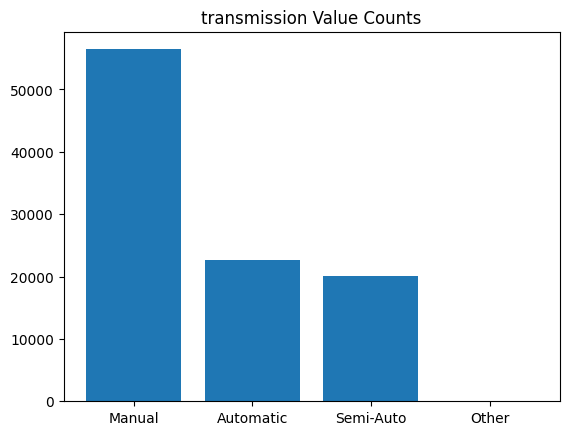

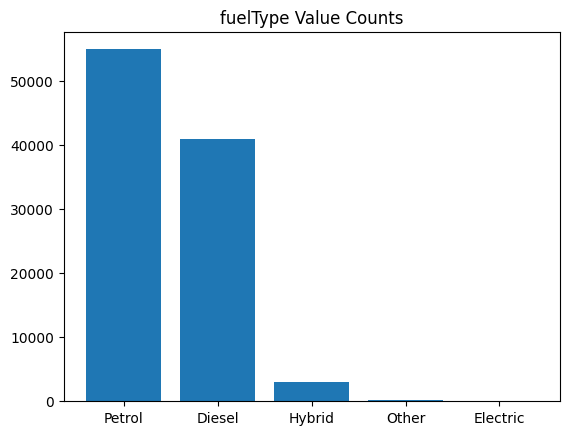

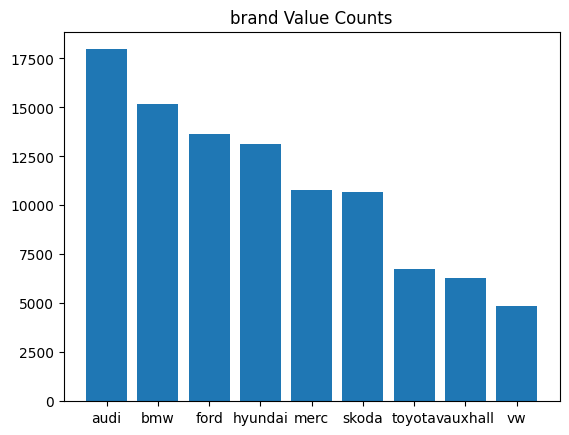

In [8]:
# 4. Plot value counts of categorical features 
categorical_cols = [col for col in df.columns if (df[col].dtype == 'str') or (df[col].dtype == 'object')]

for i in categorical_cols:
    plt.bar(df[i].unique(), df[i].value_counts())
    plt.title(f'{df[i].name} Value Counts')
    plt.show()

In [9]:
# 5. Outliers via IQR
for i in numerical_cols:
    q1 = df[i].quantile(0.25)
    q3 = df[i].quantile(0.75)
    iqr = q3 - q1

    outliers = df[(df[i] < q1 - 1.5 * iqr) | (df[i] > q3 + 1.5 * iqr)]
    
    print(f'Outliers in {df[i].name}: {outliers}\nLength: {len(outliers)}\n')

Outliers in year:       model  year  price transmission  mileage fuelType    tax   mpg  \
7403     S4  2004   6990    Automatic    88024   Petrol  325.0  22.4   
7404     A3  2009   2490       Manual   152034   Diesel  150.0  55.4   
7414     A3  2009   4495       Manual    92000   Petrol  200.0  40.9   
7415     A5  2010   9495       Manual    76000   Petrol  235.0  38.7   
7416     A3  2009   5995       Manual    82000   Petrol  235.0  39.2   
...     ...   ...    ...          ...      ...      ...    ...   ...   
99181   Eos  2006   2995       Manual    92640   Diesel  200.0  48.0   
99183   Fox  2008   1799       Manual    88102   Petrol  145.0  46.3   
99184   Fox  2009   1590       Manual    70000   Petrol  200.0  42.0   
99185   Fox  2006   1250       Manual    82704   Petrol  150.0  46.3   
99186   Fox  2007   2295       Manual    74000   Petrol  145.0  46.3   

       engineSize brand  tax(£)  
7403          4.2  audi     NaN  
7404          1.9  audi     NaN  
7414          1

1. Text values to lowercase.

2. Drop duplicates. 

3. `model`: drop.

4. `year`: drop impossible value: 2060. Creatw `df['car_age'] = 2026 - df['year']`.

5. `price`: impossible prices (min - 450, max - 159 999). Outliers. 

6. `transmission`: filter out 'other' value. Encode.

7. `mileage`: outliers. Create `df['mileage_per_year'] = df['mileage'] / (df['car_age'] + 1)`.

8. `fuelType`: 'other' values. Encode.

9. `tax`, `tax(£)`:  Merge. Outliers. Create `df['engine_tax_ratio'] = df['engineSize'] / (df['tax'] + 1)`.

10. `mpg`, `engineSize`: outliers. 

11. `brand`: Enocode.

12. Shuffle records.

### 4. Data cleaning

In [10]:
# 1. Convert text values into lower
for i in categorical_cols:
    df[i] = df[i].str.lower()

df

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,brand,tax(£)
0,a1,2017,12500,manual,15735,petrol,150.0,55.4,1.4,audi,NaN
1,a6,2016,16500,automatic,36203,diesel,20.0,64.2,2.0,audi,NaN
2,a1,2016,11000,manual,29946,petrol,30.0,55.4,1.4,audi,NaN
3,a4,2017,16800,automatic,25952,diesel,145.0,67.3,2.0,audi,NaN
4,a3,2019,17300,manual,1998,petrol,145.0,49.6,1.0,audi,NaN
...,...,...,...,...,...,...,...,...,...,...,...
99182,eos,2012,5990,manual,74000,diesel,125.0,58.9,2.0,vw,NaN
99183,fox,2008,1799,manual,88102,petrol,145.0,46.3,1.2,vw,NaN
99184,fox,2009,1590,manual,70000,petrol,200.0,42.0,1.4,vw,NaN
99185,fox,2006,1250,manual,82704,petrol,150.0,46.3,1.2,vw,NaN


In [11]:
# 2. Remove duplicate records
duplicated_records = df[df.duplicated(keep=False)]
df = df.drop_duplicates().reset_index(drop=True)

df.duplicated().sum()

np.int64(0)

In [12]:
# 3. Remove or correct impossible values
# Year
df = df[(df['year'] >= 1995) & (df['year'] <= 2026)].reset_index(drop=True)
df

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,brand,tax(£)
0,a1,2017,12500,manual,15735,petrol,150.0,55.4,1.4,audi,NaN
1,a6,2016,16500,automatic,36203,diesel,20.0,64.2,2.0,audi,NaN
2,a1,2016,11000,manual,29946,petrol,30.0,55.4,1.4,audi,NaN
3,a4,2017,16800,automatic,25952,diesel,145.0,67.3,2.0,audi,NaN
4,a3,2019,17300,manual,1998,petrol,145.0,49.6,1.0,audi,NaN
...,...,...,...,...,...,...,...,...,...,...,...
97704,eos,2012,5990,manual,74000,diesel,125.0,58.9,2.0,vw,NaN
97705,fox,2008,1799,manual,88102,petrol,145.0,46.3,1.2,vw,NaN
97706,fox,2009,1590,manual,70000,petrol,200.0,42.0,1.4,vw,NaN
97707,fox,2006,1250,manual,82704,petrol,150.0,46.3,1.2,vw,NaN


In [13]:
# Price
def remove_price_outliers(df):
    Q1 = df['price'].quantile(0.25)
    Q3 = df['price'].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df['price'] >= Q1 - 1.5*IQR) & 
                 (df['price'] <= Q3 + 1.5*IQR)]

df = remove_price_outliers(df).reset_index(drop=True)
df

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,brand,tax(£)
0,a1,2017,12500,manual,15735,petrol,150.0,55.4,1.4,audi,NaN
1,a6,2016,16500,automatic,36203,diesel,20.0,64.2,2.0,audi,NaN
2,a1,2016,11000,manual,29946,petrol,30.0,55.4,1.4,audi,NaN
3,a4,2017,16800,automatic,25952,diesel,145.0,67.3,2.0,audi,NaN
4,a3,2019,17300,manual,1998,petrol,145.0,49.6,1.0,audi,NaN
...,...,...,...,...,...,...,...,...,...,...,...
93879,eos,2012,5990,manual,74000,diesel,125.0,58.9,2.0,vw,NaN
93880,fox,2008,1799,manual,88102,petrol,145.0,46.3,1.2,vw,NaN
93881,fox,2009,1590,manual,70000,petrol,200.0,42.0,1.4,vw,NaN
93882,fox,2006,1250,manual,82704,petrol,150.0,46.3,1.2,vw,NaN


In [14]:
# Transmission
print(df['transmission'].value_counts())
df = df[df['transmission'] != 'other'].reset_index(drop=True)
df

transmission
manual       55481
semi-auto    20079
automatic    18315
other            9
Name: count, dtype: int64


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,brand,tax(£)
0,a1,2017,12500,manual,15735,petrol,150.0,55.4,1.4,audi,NaN
1,a6,2016,16500,automatic,36203,diesel,20.0,64.2,2.0,audi,NaN
2,a1,2016,11000,manual,29946,petrol,30.0,55.4,1.4,audi,NaN
3,a4,2017,16800,automatic,25952,diesel,145.0,67.3,2.0,audi,NaN
4,a3,2019,17300,manual,1998,petrol,145.0,49.6,1.0,audi,NaN
...,...,...,...,...,...,...,...,...,...,...,...
93870,eos,2012,5990,manual,74000,diesel,125.0,58.9,2.0,vw,NaN
93871,fox,2008,1799,manual,88102,petrol,145.0,46.3,1.2,vw,NaN
93872,fox,2009,1590,manual,70000,petrol,200.0,42.0,1.4,vw,NaN
93873,fox,2006,1250,manual,82704,petrol,150.0,46.3,1.2,vw,NaN


In [15]:
# Mileage
df = df[df['mileage'] < 180000].reset_index(drop=True)
df

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,brand,tax(£)
0,a1,2017,12500,manual,15735,petrol,150.0,55.4,1.4,audi,NaN
1,a6,2016,16500,automatic,36203,diesel,20.0,64.2,2.0,audi,NaN
2,a1,2016,11000,manual,29946,petrol,30.0,55.4,1.4,audi,NaN
3,a4,2017,16800,automatic,25952,diesel,145.0,67.3,2.0,audi,NaN
4,a3,2019,17300,manual,1998,petrol,145.0,49.6,1.0,audi,NaN
...,...,...,...,...,...,...,...,...,...,...,...
93857,eos,2012,5990,manual,74000,diesel,125.0,58.9,2.0,vw,NaN
93858,fox,2008,1799,manual,88102,petrol,145.0,46.3,1.2,vw,NaN
93859,fox,2009,1590,manual,70000,petrol,200.0,42.0,1.4,vw,NaN
93860,fox,2006,1250,manual,82704,petrol,150.0,46.3,1.2,vw,NaN


In [16]:
# Fuel Type
print(df['fuelType'].value_counts())
df = df[df['fuelType'].isin(['petrol', 'diesel', 'hybrid'])].reset_index(drop=True)
df

fuelType
petrol      52583
diesel      38056
hybrid       2978
other         239
electric        6
Name: count, dtype: int64


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,brand,tax(£)
0,a1,2017,12500,manual,15735,petrol,150.0,55.4,1.4,audi,NaN
1,a6,2016,16500,automatic,36203,diesel,20.0,64.2,2.0,audi,NaN
2,a1,2016,11000,manual,29946,petrol,30.0,55.4,1.4,audi,NaN
3,a4,2017,16800,automatic,25952,diesel,145.0,67.3,2.0,audi,NaN
4,a3,2019,17300,manual,1998,petrol,145.0,49.6,1.0,audi,NaN
...,...,...,...,...,...,...,...,...,...,...,...
93612,eos,2012,5990,manual,74000,diesel,125.0,58.9,2.0,vw,NaN
93613,fox,2008,1799,manual,88102,petrol,145.0,46.3,1.2,vw,NaN
93614,fox,2009,1590,manual,70000,petrol,200.0,42.0,1.4,vw,NaN
93615,fox,2006,1250,manual,82704,petrol,150.0,46.3,1.2,vw,NaN


In [17]:
# Engine Size
df = df[df['engineSize'] > 0.0].reset_index(drop=True)
df

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,brand,tax(£)
0,a1,2017,12500,manual,15735,petrol,150.0,55.4,1.4,audi,NaN
1,a6,2016,16500,automatic,36203,diesel,20.0,64.2,2.0,audi,NaN
2,a1,2016,11000,manual,29946,petrol,30.0,55.4,1.4,audi,NaN
3,a4,2017,16800,automatic,25952,diesel,145.0,67.3,2.0,audi,NaN
4,a3,2019,17300,manual,1998,petrol,145.0,49.6,1.0,audi,NaN
...,...,...,...,...,...,...,...,...,...,...,...
93363,eos,2012,5990,manual,74000,diesel,125.0,58.9,2.0,vw,NaN
93364,fox,2008,1799,manual,88102,petrol,145.0,46.3,1.2,vw,NaN
93365,fox,2009,1590,manual,70000,petrol,200.0,42.0,1.4,vw,NaN
93366,fox,2006,1250,manual,82704,petrol,150.0,46.3,1.2,vw,NaN


In [18]:
# 4. Merging redundant columns
df['Tax'] = df['tax'].combine_first(df['tax(£)'])
df = df.drop(columns=['tax', 'tax(£)'])
df = df.rename(columns={'Tax':'tax'})
df

,model,year,price,transmission,mileage,fuelType,mpg,engineSize,brand,tax
0,a1,2017,12500,manual,15735,petrol,55.4,1.4,audi,150.0
1,a6,2016,16500,automatic,36203,diesel,64.2,2.0,audi,20.0
2,a1,2016,11000,manual,29946,petrol,55.4,1.4,audi,30.0
3,a4,2017,16800,automatic,25952,diesel,67.3,2.0,audi,145.0
4,a3,2019,17300,manual,1998,petrol,49.6,1.0,audi,145.0
...,...,...,...,...,...,...,...,...,...,...
93363,eos,2012,5990,manual,74000,diesel,58.9,2.0,vw,125.0
93364,fox,2008,1799,manual,88102,petrol,46.3,1.2,vw,145.0
93365,fox,2009,1590,manual,70000,petrol,42.0,1.4,vw,200.0
93366,fox,2006,1250,manual,82704,petrol,46.3,1.2,vw,150.0


### 5. Feature engineering

In [19]:
# 1. Create ratio features
# Car age
df['car_age'] = 2026 - df['year']
df = df.drop(columns=['year'])

# Mileage per year
df['mileage_per_year'] = df['mileage'] / (df['car_age'] + 1)

# Engine tax ratio
df['engine_tax_ratio'] = df['engineSize'] / (df['tax'] + 1)

df

,model,price,transmission,mileage,fuelType,mpg,engineSize,brand,tax,car_age,mileage_per_year,engine_tax_ratio
0,a1,12500,manual,15735,petrol,55.4,1.4,audi,150.0,9,1573.500000,0.009272
1,a6,16500,automatic,36203,diesel,64.2,2.0,audi,20.0,10,3291.181818,0.095238
2,a1,11000,manual,29946,petrol,55.4,1.4,audi,30.0,10,2722.363636,0.045161
3,a4,16800,automatic,25952,diesel,67.3,2.0,audi,145.0,9,2595.200000,0.013699
4,a3,17300,manual,1998,petrol,49.6,1.0,audi,145.0,7,249.750000,0.006849
...,...,...,...,...,...,...,...,...,...,...,...,...
93363,eos,5990,manual,74000,diesel,58.9,2.0,vw,125.0,14,4933.333333,0.015873
93364,fox,1799,manual,88102,petrol,46.3,1.2,vw,145.0,18,4636.947368,0.008219
93365,fox,1590,manual,70000,petrol,42.0,1.4,vw,200.0,17,3888.888889,0.006965
93366,fox,1250,manual,82704,petrol,46.3,1.2,vw,150.0,20,3938.285714,0.007947


In [20]:
# 2. Adding real market distinction: premium vs. mainstream
premium_brands = ['audi', 'bmw', 'merc']
df['is_premium'] = df['brand'].isin(premium_brands).astype(int)
df

,model,price,transmission,mileage,fuelType,mpg,engineSize,brand,tax,car_age,mileage_per_year,engine_tax_ratio,is_premium
0,a1,12500,manual,15735,petrol,55.4,1.4,audi,150.0,9,1573.500000,0.009272,1
1,a6,16500,automatic,36203,diesel,64.2,2.0,audi,20.0,10,3291.181818,0.095238,1
2,a1,11000,manual,29946,petrol,55.4,1.4,audi,30.0,10,2722.363636,0.045161,1
3,a4,16800,automatic,25952,diesel,67.3,2.0,audi,145.0,9,2595.200000,0.013699,1
4,a3,17300,manual,1998,petrol,49.6,1.0,audi,145.0,7,249.750000,0.006849,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
93363,eos,5990,manual,74000,diesel,58.9,2.0,vw,125.0,14,4933.333333,0.015873,0
93364,fox,1799,manual,88102,petrol,46.3,1.2,vw,145.0,18,4636.947368,0.008219,0
93365,fox,1590,manual,70000,petrol,42.0,1.4,vw,200.0,17,3888.888889,0.006965,0
93366,fox,1250,manual,82704,petrol,46.3,1.2,vw,150.0,20,3938.285714,0.007947,0


### 6. Train Test Split

In [21]:
# Shuffle data records before splitting
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df

,model,price,transmission,mileage,fuelType,mpg,engineSize,brand,tax,car_age,mileage_per_year,engine_tax_ratio,is_premium
0,tiguan,16895,manual,28619,diesel,58.9,2.0,vw,145.0,9,2861.900000,0.013699,0
1,3 series,13999,manual,52713,diesel,64.2,2.0,bmw,30.0,10,4792.090909,0.064516,1
2,c class,15999,semi-auto,31273,petrol,52.3,2.0,merc,125.0,12,2405.615385,0.015873,1
3,adam,7200,manual,24069,petrol,52.3,1.4,vauxhall,125.0,11,2005.750000,0.011111,0
4,4 series,15995,semi-auto,48552,diesel,60.1,2.0,bmw,125.0,10,4413.818182,0.015873,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
93363,q2,22950,manual,5786,petrol,40.9,1.5,audi,145.0,7,723.250000,0.010274,1
93364,fabia,7552,manual,21159,petrol,60.1,1.2,skoda,20.0,10,1923.545455,0.057143,0
93365,adam,9499,manual,3569,petrol,53.3,1.2,vauxhall,145.0,8,396.555556,0.008219,0
93366,q2,20498,semi-auto,5662,diesel,47.9,1.6,audi,145.0,7,707.750000,0.010959,1


In [22]:
# Split data
X = df.drop(columns=['price'])
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print()
print(X_test.shape)

(74694, 12)

(18674, 12)


### 7. Stateful preprocessing

In [23]:
# Encoding Categorical Columns (Excluded: 'model')
categorical_cols = [col for col in df.columns if ((df[col].dtype == 'str') or (df[col].dtype == 'object')) and (df[col].name != 'model')] # Updating the list

encoder = OneHotEncoder(drop='first')

# Encoding training dataset
encoded_train_data = encoder.fit_transform(X_train[categorical_cols])
encoded_train_df = pd.DataFrame(
    encoded_train_data.toarray(),
    columns=encoder.get_feature_names_out(),
    index=X_train.index
)

X_train = pd.concat([X_train.drop(columns=categorical_cols), encoded_train_df], axis=1)

# Encoding test dataset
encoded_test_data = encoder.transform(X_test[categorical_cols])
encoded_test_df = pd.DataFrame(
    encoded_test_data.toarray(),
    columns=encoder.get_feature_names_out(),
    index=X_test.index
)

X_test = pd.concat([X_test.drop(columns=categorical_cols), encoded_test_df], axis=1)

In [24]:
X_train

,model,mileage,mpg,engineSize,tax,car_age,mileage_per_year,engine_tax_ratio,is_premium,transmission_manual,...,fuelType_hybrid,fuelType_petrol,brand_bmw,brand_ford,brand_hyundai,brand_merc,brand_skoda,brand_toyota,brand_vauxhall,brand_vw
44606,a4,41505,67.3,2.0,20.0,10,3773.181818,0.095238,1,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
59691,3 series,8389,47.9,2.0,145.0,7,1048.625000,0.013699,1,0.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
49041,polo,23326,65.7,1.0,0.0,10,2120.545455,1.000000,0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
42031,yaris,42000,58.9,1.5,145.0,8,4666.666667,0.010274,0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
28290,fiesta,16143,54.3,1.2,125.0,9,1614.300000,0.009524,0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6265,astra,1336,54.3,1.2,145.0,6,190.857143,0.008219,0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
54886,mokka,17982,44.8,1.4,160.0,10,1634.727273,0.008696,0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
76820,octavia,72382,70.6,2.0,20.0,9,7238.200000,0.095238,0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
860,aygo,24619,69.0,1.0,0.0,11,2051.583333,1.000000,0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [25]:
X_test

,model,mileage,mpg,engineSize,tax,car_age,mileage_per_year,engine_tax_ratio,is_premium,transmission_manual,...,fuelType_hybrid,fuelType_petrol,brand_bmw,brand_ford,brand_hyundai,brand_merc,brand_skoda,brand_toyota,brand_vauxhall,brand_vw
88798,up,20817,64.2,1.0,150.0,9,2081.700000,0.006623,0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
16435,fiesta,46028,54.3,1.2,30.0,13,3287.714286,0.038710,0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
46631,up,41088,64.2,1.0,20.0,10,3735.272727,0.047619,0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
76886,tucson,6155,51.4,1.6,145.0,7,769.375000,0.010959,0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
15099,t-roc,5113,39.8,1.5,145.0,8,568.111111,0.010274,0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75513,tucson,28000,61.7,1.7,30.0,9,2800.000000,0.054839,0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
48147,corsa,35507,49.6,1.4,145.0,8,3945.222222,0.009589,0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
83249,sharan,33052,50.4,2.0,165.0,11,2754.333333,0.012048,0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
52631,focus,3037,57.7,1.0,145.0,8,337.444444,0.006849,0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [26]:
# Encoding 'model' Column
target = TargetEncoder(smoothing=10)

# Encoding training dataset
X_train['model'] = target.fit_transform(X_train['model'], y_train)

# Encoding testing dataset
X_test['model'] = target.transform(X_test['model'])


In [27]:
X_train

,model,mileage,mpg,engineSize,tax,car_age,mileage_per_year,engine_tax_ratio,is_premium,transmission_manual,...,fuelType_hybrid,fuelType_petrol,brand_bmw,brand_ford,brand_hyundai,brand_merc,brand_skoda,brand_toyota,brand_vauxhall,brand_vw
44606,19079.934211,41505,67.3,2.0,20.0,10,3773.181818,0.095238,1,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
59691,19002.548653,8389,47.9,2.0,145.0,7,1048.625000,0.013699,1,0.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
49041,11336.849727,23326,65.7,1.0,0.0,10,2120.545455,1.000000,0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
42031,10576.626036,42000,58.9,1.5,145.0,8,4666.666667,0.010274,0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
28290,10186.670842,16143,54.3,1.2,125.0,9,1614.300000,0.009524,0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6265,10279.360969,1336,54.3,1.2,145.0,6,190.857143,0.008219,0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
54886,8986.243789,17982,44.8,1.4,160.0,10,1634.727273,0.008696,0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
76820,13921.375554,72382,70.6,2.0,20.0,9,7238.200000,0.095238,0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
860,7820.600939,24619,69.0,1.0,0.0,11,2051.583333,1.000000,0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [28]:
X_test

,model,mileage,mpg,engineSize,tax,car_age,mileage_per_year,engine_tax_ratio,is_premium,transmission_manual,...,fuelType_hybrid,fuelType_petrol,brand_bmw,brand_ford,brand_hyundai,brand_merc,brand_skoda,brand_toyota,brand_vauxhall,brand_vw
88798,7977.452135,20817,64.2,1.0,150.0,9,2081.700000,0.006623,0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
16435,10186.670842,46028,54.3,1.2,30.0,13,3287.714286,0.038710,0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
46631,7977.452135,41088,64.2,1.0,20.0,10,3735.272727,0.047619,0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
76886,15762.356513,6155,51.4,1.6,145.0,7,769.375000,0.010959,0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
15099,22621.310036,5113,39.8,1.5,145.0,8,568.111111,0.010274,0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75513,15762.356513,28000,61.7,1.7,30.0,9,2800.000000,0.054839,0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
48147,8095.541714,35507,49.6,1.4,145.0,8,3945.222222,0.009589,0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
83249,22020.388767,33052,50.4,2.0,165.0,11,2754.333333,0.012048,0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
52631,13200.794498,3037,57.7,1.0,145.0,8,337.444444,0.006849,0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


Since proposed algorithms require two different versions of scaled dataset, **normalization** will be done through pipelines during model selection phase.

### 8. Model selection

In [29]:
# 1. Random Forest Regressor
preprocessor = ColumnTransformer(
    transformers=[
        ('scale', StandardScaler(), [col for col in X_train.columns if not(
            col == 'is_premium'
            or
            col.startswith('transmission')
            or
            col.startswith('fuelType')
            or
            col.startswith('brand')
        )])
    ],
    remainder = 'passthrough'
)

rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('rfregressor', RandomForestRegressor(
        n_estimators=100,
        max_depth=20,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ))
]).set_output(transform='pandas')

In [30]:
# 2. Ridge Regressor
ridge_model = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('ridgeregressor', Ridge(
        alpha=1.0
    ))
])

In [31]:
# 3. MLP/ Dense Neural Network
# 3.1. Build MLP model as a function to pass to Pipeline
def build_mlp(meta):
    n_features = meta['n_features_in_']

    model = Sequential([
        Input(shape=(n_features,)),    # Automatically detects number of columns
        Dense(128, activation='relu'),  # Hidden layer 1
        Dropout(0.2),   # Prevents memorizing the training data
        Dense(64, activation='relu'), # Hidden layer 2
        Dense(32, activation='relu'),   # Hidden layer 3
        Dense(1)    # Output layer
    ])

    model.compile(
        optimizer='adam',
        loss='mae'  # MAE: Mean Aboslute Error is usually better for car prices
    )

    return model

# Applying neural network to pipeline
mlp_model = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('mlp', KerasRegressor(
        model = build_mlp,
        epochs=100,
        batch_size=32,
        validation_split=0.2,
        callbacks=[
            EarlyStopping(
                monitor='val_loss',
                patience=10,
                restore_best_weights=True
            )   # Stop training when the model stops improving to save time
        ],
        verbose=1
    ))
])

In [32]:
# Establish a baseline first

# create baseline regressor (mean strategy)
baseline = DummyRegressor(
    strategy='mean'
)

baseline.fit(X_train, y_train)

# predictions and standard metrics
y_pred_baseline = baseline.predict(X_test)

print(f'Baseline R2: {baseline.score(X_test, y_test):.4f}\nBaseline RMSE: {root_mean_squared_error(y_test, y_pred_baseline):.2f}\nBaseline MAE: {mean_absolute_error(y_test, y_pred_baseline):.2f}')

Baseline R2: -0.0001
Baseline RMSE: 7195.98
Baseline MAE: 5859.80


In [33]:
# Candidates models
models = {
    'RandomForest': rf_model,
    'Ridge': ridge_model,
    'MLP': mlp_model
}

### 9. Train & cross-validate

In [34]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    'r2': 'r2',
    'neg_mse': 'neg_mean_squared_error',
    'neg_rmse': 'neg_root_mean_squared_error',
    'neg_mae': 'neg_mean_absolute_error'
}

for name, model in models.items():
    # cross_val_score only sees X_train — test set stays sealed
    res = cross_validate(
        model,
        X_train, y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False
    )

    print(f'Model: {name}\n')
    print(f'Validate R2: {res['test_r2'].mean():.3f} +/- {res['test_r2'].std():.3f}\n')
    print(f'Validate MSE: {-res['test_neg_mse'].mean():.2f}\n')
    print(f'Validate RMSE: {-res['test_neg_rmse'].mean():.2f}\n')
    print(f'Validate MAE: {-res['test_neg_mae'].mean():.2f}\n')

Model: RandomForest

Validate R2: 0.957 +/- 0.001

Validate MSE: 2214356.14

Validate RMSE: 1488.03

Validate MAE: 1034.41

Model: Ridge

Validate R2: 0.880 +/- 0.001

Validate MSE: 6160882.09

Validate RMSE: 2482.08

Validate MAE: 1850.80

Epoch 1/100
1494/1494 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 3955.5315 - val_loss: 1611.3391
Epoch 2/100
1494/1494 ━━━━━━━━━━━━━━━━━━━━ 1s 943us/step - loss: 1755.2092 - val_loss: 1534.2527
Epoch 3/100
1494/1494 ━━━━━━━━━━━━━━━━━━━━ 1s 952us/step - loss: 1699.9780 - val_loss: 1503.1283
Epoch 4/100
1494/1494 ━━━━━━━━━━━━━━━━━━━━ 1s 952us/step - loss: 1673.6693 - val_loss: 1468.9459
Epoch 5/100
1494/1494 ━━━━━━━━━━━━━━━━━━━━ 2s 997us/step - loss: 1658.1188 - val_loss: 1464.6730
Epoch 6/100
1494/1494 ━━━━━━━━━━━━━━━━━━━━ 1s 968us/step - loss: 1638.0448 - val_loss: 1449.1903
Epoch 7/100
1494/1494 ━━━━━━━━━━━━━━━━━━━━ 1s 946us/step - loss: 1632.6333 - val_loss: 1428.2311
Epoch 8/100
1494/1494 ━━━━━━━━━━━━━━━━━━━━ 1s 944us/step - loss: 1618.4351 - val_l

#### Model Comparison

| Model | R² (mean±std) | MSE (mean) | RMSE (mean) | MAE (mean) |
| --- | --- | --- | --- | --- |
| Random Forest | 0.957 ± 0.001 | 2214356.14 | 1488.03 | 1034.41 |
| Ridge | 0.880 ± 0.001 | 6160882.09 | 2482.08 | 1850.80 |
| MLP | 0.935 ± 0.005 | 3344255.10 | 1827.34 | 1266.15 |

Random forest regressor outperforms the rest 2. Therefore, the best model would be Random Forest Regressor

In [35]:
# Train best candidate on the full training set
best_model = rf_model
best_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('rfregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scale', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

### 10. Hyperparameter tuning

In [37]:
rf_param_distributions = {
    'rfregressor__n_estimators': [100, 300, 500],
    'rfregressor__max_depth': [10, 20, 30, None],
    'rfregressor__min_samples_split': randint(2, 11),   # samples integers from 2 to 10
    'rfregressor__min_samples_leaf': randint(1, 5), # samples integers from 1 to 4
    'rfregressor__max_features': ['sqrt', 'log2', 0.5]
} # the key you used in model definition should be added with a '_' so the grid knows which model to address. Here we're finding best values for out selected candidate model only.

random_search = RandomizedSearchCV(
    rf_model,
    rf_param_distributions,
    n_iter=50,  # 50 random combos instead of 324 exhaustive
    cv=5,
    scoring=scoring,
    refit='r2',   # ← pick the metric to optimize for
    n_jobs=1,
    random_state=42,
)
random_search.fit(X_train, y_train)

best_idx = random_search.best_index_
results = random_search.cv_results_

print(f'Best params: {random_search.best_params_}\n')

for metric in scoring:
    mean = results[f'mean_test_{metric}'][best_idx]
    std = results[f'std_test_{metric}'][best_idx]
    
    if metric.startswith('neg_'):
        print(f'{metric}: {-mean:.3f} ± {std:.3f}')
    else:
        print(f'{metric}: {mean:.3f} ± {std:.3f}')
    print()

Best params: {'rfregressor__max_depth': 30, 'rfregressor__max_features': 0.5, 'rfregressor__min_samples_leaf': 1, 'rfregressor__min_samples_split': 9, 'rfregressor__n_estimators': 500}

r2: 0.959 ± 0.001

neg_mse: 2110461.353 ± 38613.801

neg_rmse: 1452.681 ± 13.337

neg_mae: 1011.810 ± 4.845



In [38]:
best_model = random_search.best_estimator_

### 11. Evaluate on test set

In [39]:
# Applying best model to test set
y_pred = best_model.predict(X_test)

print(f'Model: Random Forest Regressor')
print(f'R2: {r2_score(y_test, y_pred):.2f}\nMSE: {mean_squared_error(y_test, y_pred):.2f}\nRMSE: {root_mean_squared_error(y_test, y_pred):.2f}\nMAE: {mean_absolute_error(y_test, y_pred):.2f}')

Model: Random Forest Regressor
R2: 0.96
MSE: 2051919.56
RMSE: 1432.45
MAE: 998.02
